### Experimental Setup

In [ ]:
FEATURE_SELECTION_METHOD = "WOA"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "BERT"
DATASET_NAME = "Filetop"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Python Version Checking

In [ ]:
# ============================================================
# Python Environment Verification
# ============================================================

# Display the current Python version to ensure compatibility
# with the required libraries and experimental setup

!python --version

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Python 3.10.20


### GPU Checking

In [ ]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Fri Mar 20 01:01:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   34C    P8             12W /  300W |   48286MiB /  49140MiB |     11%      Default |
|           

### Import Necessary Packages

In [ ]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import time
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
)
from scipy.sparse import hstack, csr_matrix

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# Transformers
# ============================================================
from transformers import (
    BertTokenizer,
    TFBertModel,
    GPT2Tokenizer,
    TFGPT2Model,
)

# ============================================================
from sklearn.linear_model import LogisticRegression
import joblib

### GPU Status Checking

In [ ]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [ ]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")

    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")

    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [ ]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Reads,Total_Writes,Total_Read_Data_Transfer,Total_Write_Data_Transfer,Read_Processes,Write_Processes,Read_Data_Transfer_Processes,Write_Data_Transfer_Processes,File_Access_Processes,Level
0,10Cent10-999.0.4.tar.gz,1345126,711470,273890605,580106,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pgrep, pip, StreamTrans, sqld...",1
1,10Cent11-999.0.4.tar.gz,1192399,585508,251798360,547692,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pgrep, pip, sqldb:c~lite, Str...",1
2,11Cent-999.0.0.tar.gz,1083052,648800,233980925,463210,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pip, pgrep, sqldb:c~lite, Str...",1
3,11Cent-999.0.1.tar.gz,1010263,560585,211948676,448241,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pip, pgrep, sqldb:c~lite, Str...",1
4,11Cent-999.0.2.tar.gz,928456,520884,201673655,441561,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pip, pgrep, sqldb:c~lite, Str...",1


### Clear Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Feature Processing

In [ ]:
# ============================================================
# Metadata Preprocessing and Feature Construction
# ============================================================

# Remove non-informative identifier column if present
if 'Package_Name' in data.columns:
    data = data.drop(columns=['Package_Name'])

# ------------------------------------------------------------
# Step 1: Construct a unified categorical text representation
# ------------------------------------------------------------

# Identify categorical feature columns, excluding the target label
categorical_columns = [
    col for col in data.columns
    if data[col].dtype == 'object' and col != 'Level'
]

# Concatenate all categorical attributes into a single text feature
data['Combined_Categorical'] = (
    data[categorical_columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

# Vectorize the combined categorical feature using bi-grams and tri-grams
vectorizer = CountVectorizer(ngram_range=(2, 3))
categorical_ngram_features = vectorizer.fit_transform(data['Combined_Categorical'])

# ------------------------------------------------------------
# Step 2: Extract and prepare numerical features
# ------------------------------------------------------------

# Select only valid numerical columns, excluding the target label
numerical_columns = [
    col for col in data.columns
    if pd.to_numeric(data[col], errors='coerce').notnull().all() and col != 'Level'
]

# Convert numerical features to float and handle missing values
numerical_features = data[numerical_columns].fillna(0).astype(float)

# Transform numerical features into sparse representation
numerical_features_sparse = csr_matrix(numerical_features.values)

# ------------------------------------------------------------
# Step 3: Combine categorical and numerical representations
# ------------------------------------------------------------

# Concatenate sparse numerical features with categorical n-gram features
X = hstack([numerical_features_sparse, categorical_ngram_features])

# ------------------------------------------------------------
# Step 4: Feature scaling
# ------------------------------------------------------------

# Standardize the combined sparse feature matrix
# Note: with_mean=False is required for sparse matrices
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

### Selected Features

In [ ]:
selected_features = ['Total_Reads', 'Total_Write_Data_Transfer', 'Read_Processes', 'Read_Data_Transfer_Processes', 'Write_Data_Transfer_Processes', 'File_Access_Processes']

### Data Preprocessing

In [ ]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 6)
Validation set shape   : (2141, 6)
Test set shape         : (2141, 6)


### Setup OUTPUT_DIR

In [ ]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Filetop_WOA_Attention_BERT'

### Model

In [ ]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")

# ==========================
# Convert each row into a single text string
# ==========================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        text = " ".join([f"{col}:{row[col]}" for col in df.columns])
        texts.append(text)
    return texts

train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)

# ==========================
# Load TensorFlow-compatible BERT tokenizer
# ==========================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

max_len = 128

train_enc = tokenizer(train_texts, padding="max_length", truncation=True, max_length=max_len, return_tensors="tf")
val_enc   = tokenizer(val_texts, padding="max_length", truncation=True, max_length=max_len, return_tensors="tf")
test_enc  = tokenizer(test_texts, padding="max_length", truncation=True, max_length=max_len, return_tensors="tf")


# ==========================
# Labels
# ==========================
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(
    filepath=MODEL_NAME,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=200,
    restore_best_weights=True
)


# ==========================
# Load TensorFlow BERT
# ==========================
bert = TFBertModel.from_pretrained("bert-base-uncased", from_pt=False)

# ==========================
# Build TensorFlow classification model
# ==========================
input_ids = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

bert_outputs = bert(input_ids, attention_mask=attention_mask)
cls_token = bert_outputs.last_hidden_state[:, 0, :]  # CLS token

x = tf.keras.layers.Dense(128, activation="relu")(cls_token)
x = tf.keras.layers.Dropout(0.3)(x)

output_layer = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output_layer)


# ==========================
# Compile model
# ==========================
model.compile(
    tf.keras.optimizers.legacy.Adam(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 128)]        0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 128)]        0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  109482240   ['input_ids[0][0]',              
                                thPoolingAndCrossAt               'attention_mask[0][0]']         
                                tentions(last_hidde                                               
                                n_state=(None, 128,                                           

### Compime the Model

In [ ]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    {"input_ids": train_enc["input_ids"], "attention_mask": train_enc["attention_mask"]},
    y_train,
    validation_data=(
        {"input_ids": val_enc["input_ids"], "attention_mask": val_enc["attention_mask"]},
        y_val
    ),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb]
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200

Epoch 1: val_accuracy improved from -inf to 0.84353, saving model to Evaluation_Outputs_Filetop_WOA_Attention_BERT\Evaluation_Outputs_Filetop_WOA_Attention_BERT.h5
625/625 [==============================] - 69s 86ms/step - loss: 0.4051 - accuracy: 0.8008 - val_loss: 0.3352 - val_accuracy: 0.8435 - lr: 2.0000e-05
Epoch 2/200

Epoch 2: val_accuracy improved from 0.84353 to 0.87436, saving model to Evaluation_Outputs_Filetop_WOA_Attention_BERT\Evaluation_Outputs_Filetop_WOA_Attention_BERT.h5
625/625 [==============================] - 51s 81ms/step - loss: 0.3130 - accuracy: 0.8536 - val_loss: 0.2880 - val_accuracy: 0.8744 - lr: 2.0000e-05
Epoch 3/200

Epoch 3: val_accuracy improved from 0.87436 to 0.87482, saving model to Evaluation_Outputs_Filetop_WOA_Attention_BERT\Evaluation_Outputs_Filetop_WOA_Attention_BERT.h5
625/625 [==============================] - 51s 81ms/step - loss: 0.2895 - accuracy: 0.8609 - val_loss: 0.2896 - val_accuracy: 0.8748 - lr: 2.0000e-05
Epoch 4/200



625/625 [==============================] - ETA: 0s - loss: 0.0059 - accuracy: 0.9985
Epoch 80: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 134ms/step - loss: 0.0059 - accuracy: 0.9985 - val_loss: 0.1071 - val_accuracy: 0.9790 - lr: 2.0000e-05
Epoch 81/200
625/625 [==============================] - ETA: 0s - loss: 0.0020 - accuracy: 0.9994
Epoch 81: val_accuracy did not improve from 0.98599
625/625 [==============================] - 84s 134ms/step - loss: 0.0020 - accuracy: 0.9994 - val_loss: 0.1475 - val_accuracy: 0.9818 - lr: 2.0000e-05
Epoch 82/200
625/625 [==============================] - ETA: 0s - loss: 0.0022 - accuracy: 0.9996
Epoch 82: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0022 - accuracy: 0.9996 - val_loss: 0.1009 - val_accuracy: 0.9813 - lr: 2.0000e-05
Epoch 83/200
625/625 [==============================] - ETA: 0s - loss: 0.0065 - accuracy: 0.9979
Epoch 83: va

Epoch 134/200
625/625 [==============================] - ETA: 0s - loss: 0.0016 - accuracy: 0.9994
Epoch 134: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0016 - accuracy: 0.9994 - val_loss: 0.1832 - val_accuracy: 0.9823 - lr: 2.0000e-05
Epoch 135/200
625/625 [==============================] - ETA: 0s - loss: 8.1122e-04 - accuracy: 0.9997
Epoch 135: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 8.1122e-04 - accuracy: 0.9997 - val_loss: 0.2405 - val_accuracy: 0.9785 - lr: 2.0000e-05
Epoch 136/200
625/625 [==============================] - ETA: 0s - loss: 0.0019 - accuracy: 0.9996
Epoch 136: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0019 - accuracy: 0.9996 - val_loss: 0.2051 - val_accuracy: 0.9823 - lr: 2.0000e-05
Epoch 137/200
625/625 [==============================] - ETA: 0s - loss: 0.0067 - a

Epoch 161/200
625/625 [==============================] - ETA: 0s - loss: 0.0118 - accuracy: 0.9975
Epoch 161: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0118 - accuracy: 0.9975 - val_loss: 0.0678 - val_accuracy: 0.9813 - lr: 2.0000e-05
Epoch 162/200
625/625 [==============================] - ETA: 0s - loss: 0.0135 - accuracy: 0.9954
Epoch 162: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0135 - accuracy: 0.9954 - val_loss: 0.1007 - val_accuracy: 0.9809 - lr: 2.0000e-05
Epoch 163/200
625/625 [==============================] - ETA: 0s - loss: 0.0053 - accuracy: 0.9982
Epoch 163: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0053 - accuracy: 0.9982 - val_loss: 0.1146 - val_accuracy: 0.9809 - lr: 2.0000e-05
Epoch 164/200
625/625 [==============================] - ETA: 0s - loss: 0.0018 - accuracy:

Epoch 188/200
625/625 [==============================] - ETA: 0s - loss: 0.0042 - accuracy: 0.9995
Epoch 188: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0042 - accuracy: 0.9995 - val_loss: 0.1562 - val_accuracy: 0.9776 - lr: 2.0000e-05
Epoch 189/200
625/625 [==============================] - ETA: 0s - loss: 0.0029 - accuracy: 0.9993
Epoch 189: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0029 - accuracy: 0.9993 - val_loss: 0.1604 - val_accuracy: 0.9780 - lr: 2.0000e-05
Epoch 190/200
625/625 [==============================] - ETA: 0s - loss: 0.0031 - accuracy: 0.9995
Epoch 190: val_accuracy did not improve from 0.98599
625/625 [==============================] - 83s 133ms/step - loss: 0.0031 - accuracy: 0.9995 - val_loss: 0.1806 - val_accuracy: 0.9757 - lr: 2.0000e-05
Epoch 191/200
625/625 [==============================] - ETA: 0s - loss: 0.0030 - accuracy:

### Clear Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [ ]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(
    {"input_ids": val_enc["input_ids"], "attention_mask": val_enc["attention_mask"]},
    y_val,
    verbose=0
)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(
    {"input_ids": test_enc["input_ids"], "attention_mask": test_enc["attention_mask"]},
    y_test,
    verbose=0
)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 9924.63 seconds
Validation Time: 3.31 seconds
Testing Time: 3.28 seconds

Validation Accuracy: 0.8566
Test Accuracy: 0.8529


### Save Training Log

In [ ]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Filetop_WOA_Attention_BERT\training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.405090,0.800781,0.335204,0.843531,0.00002
1,2,0.312975,0.853639,0.288048,0.874358,0.00002
2,3,0.289457,0.860947,0.289552,0.874825,0.00002
3,4,0.267141,0.872960,0.256589,0.877160,0.00002
4,5,0.254895,0.883972,0.262253,0.885100,0.00002


### Trainig and Validation Plot

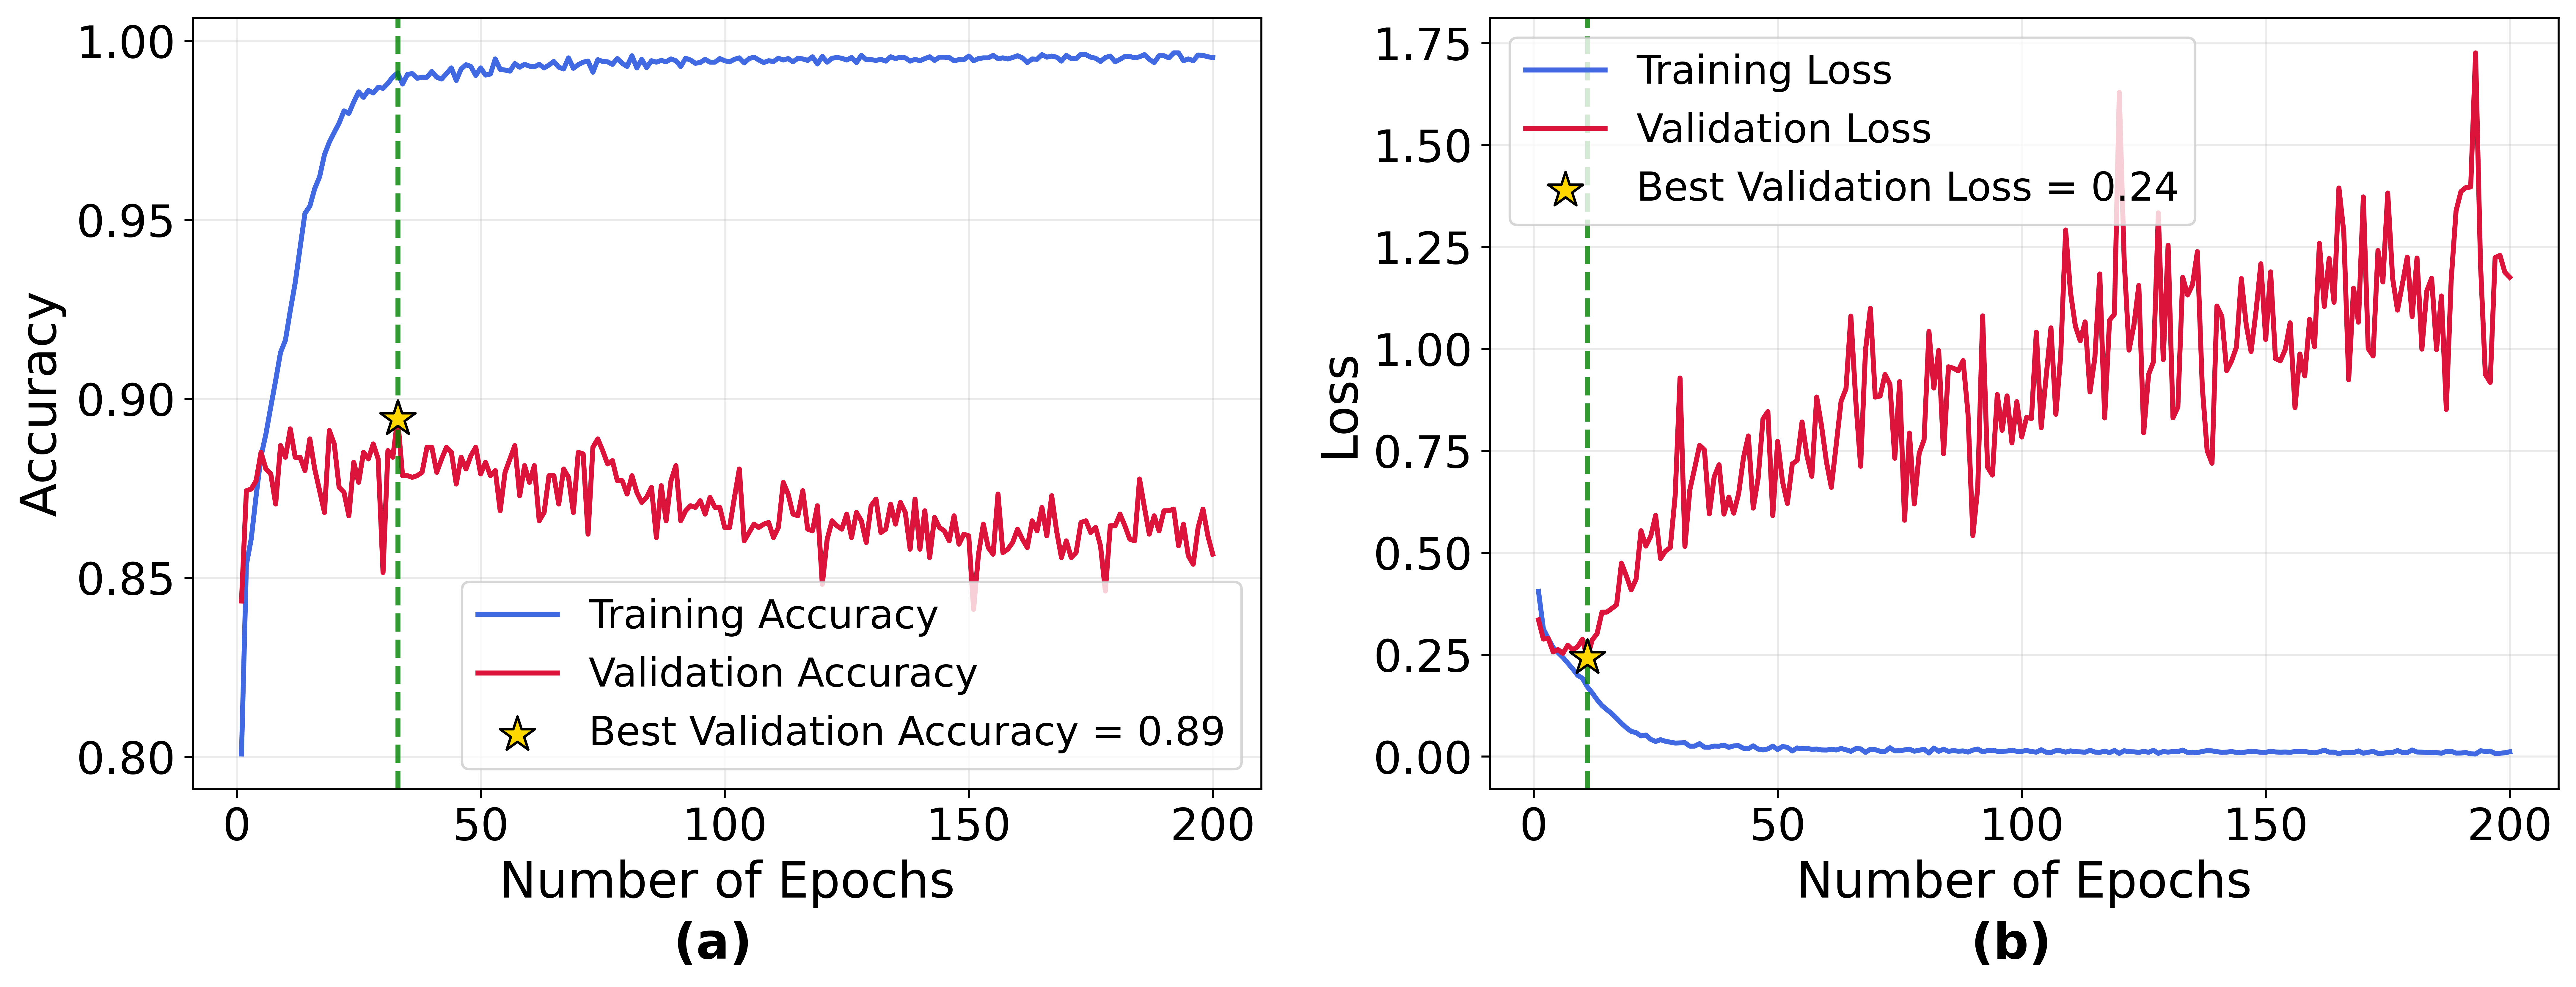

In [ ]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")

# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")

# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.994794
Precision : 0.989685
Recall    : 1.000000
F1-score  : 0.994816
ROC AUC   : 0.999736
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   1.000000  0.989600  0.994773      5000
         1.0   0.989685  1.000000  0.994816      4989

    accuracy                       0.994794      9989
   macro avg   0.994842  0.994800  0.994794      9989
weighted avg   0.994848  0.994794  0.994794      9989



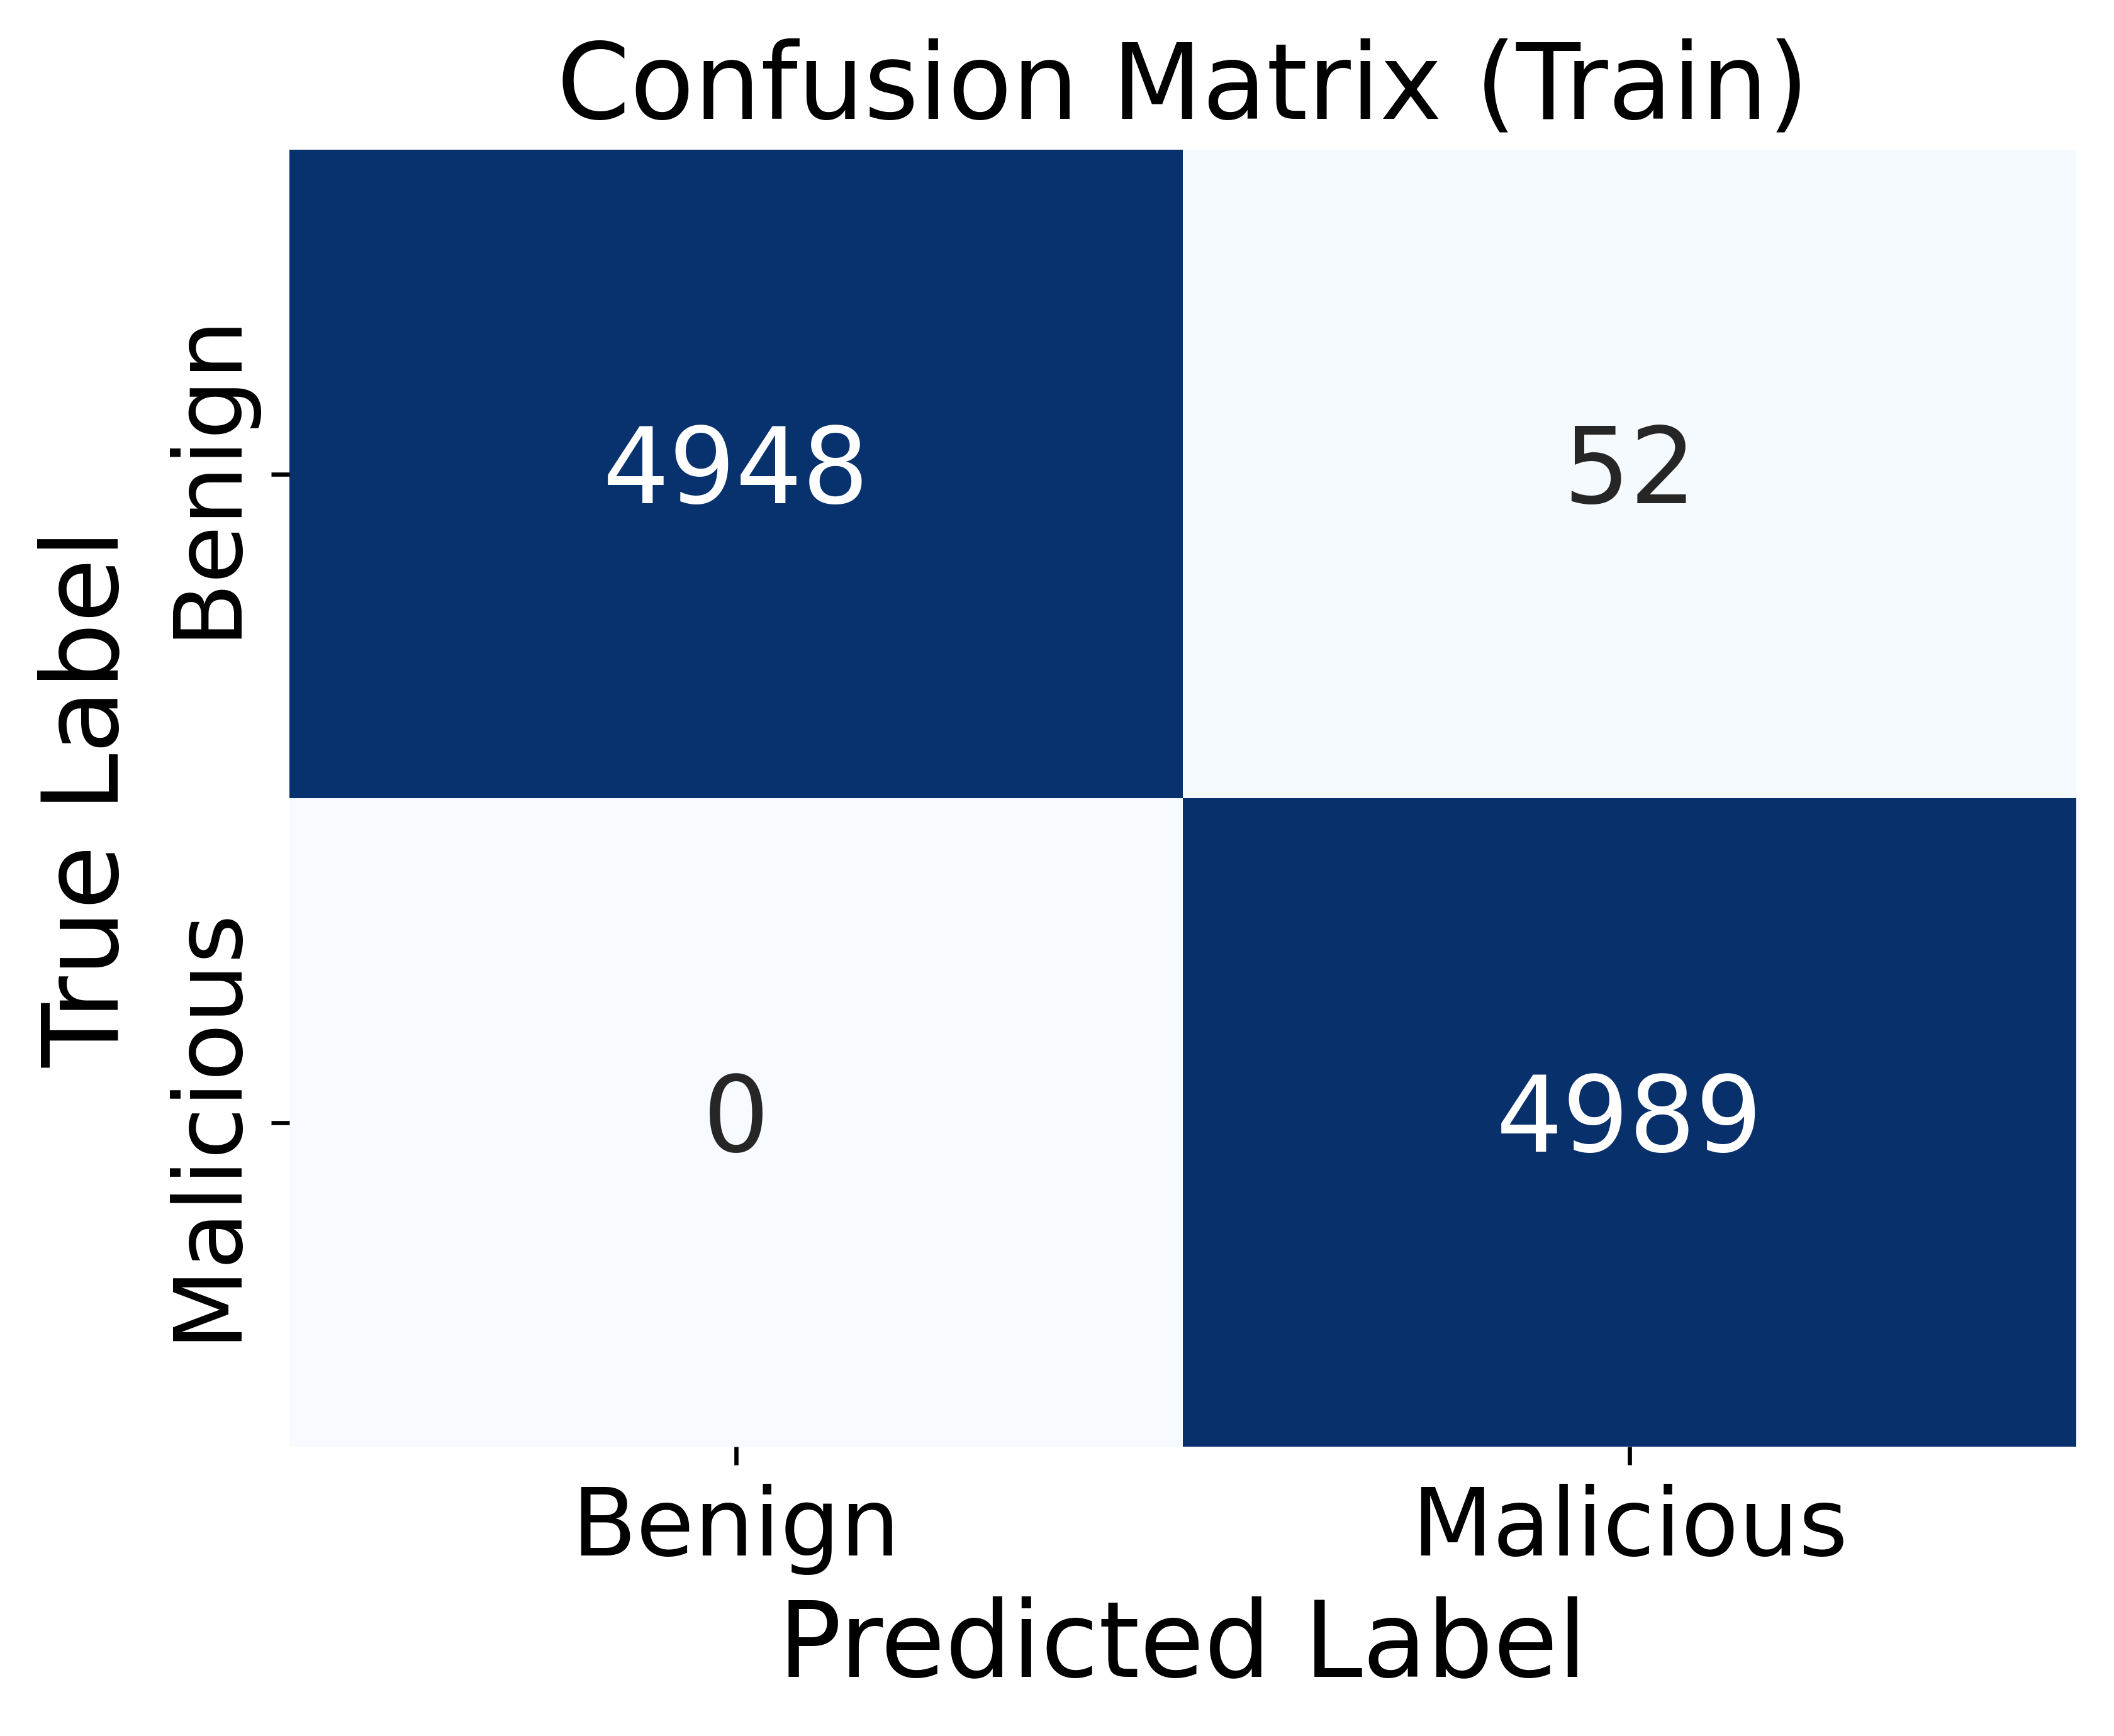

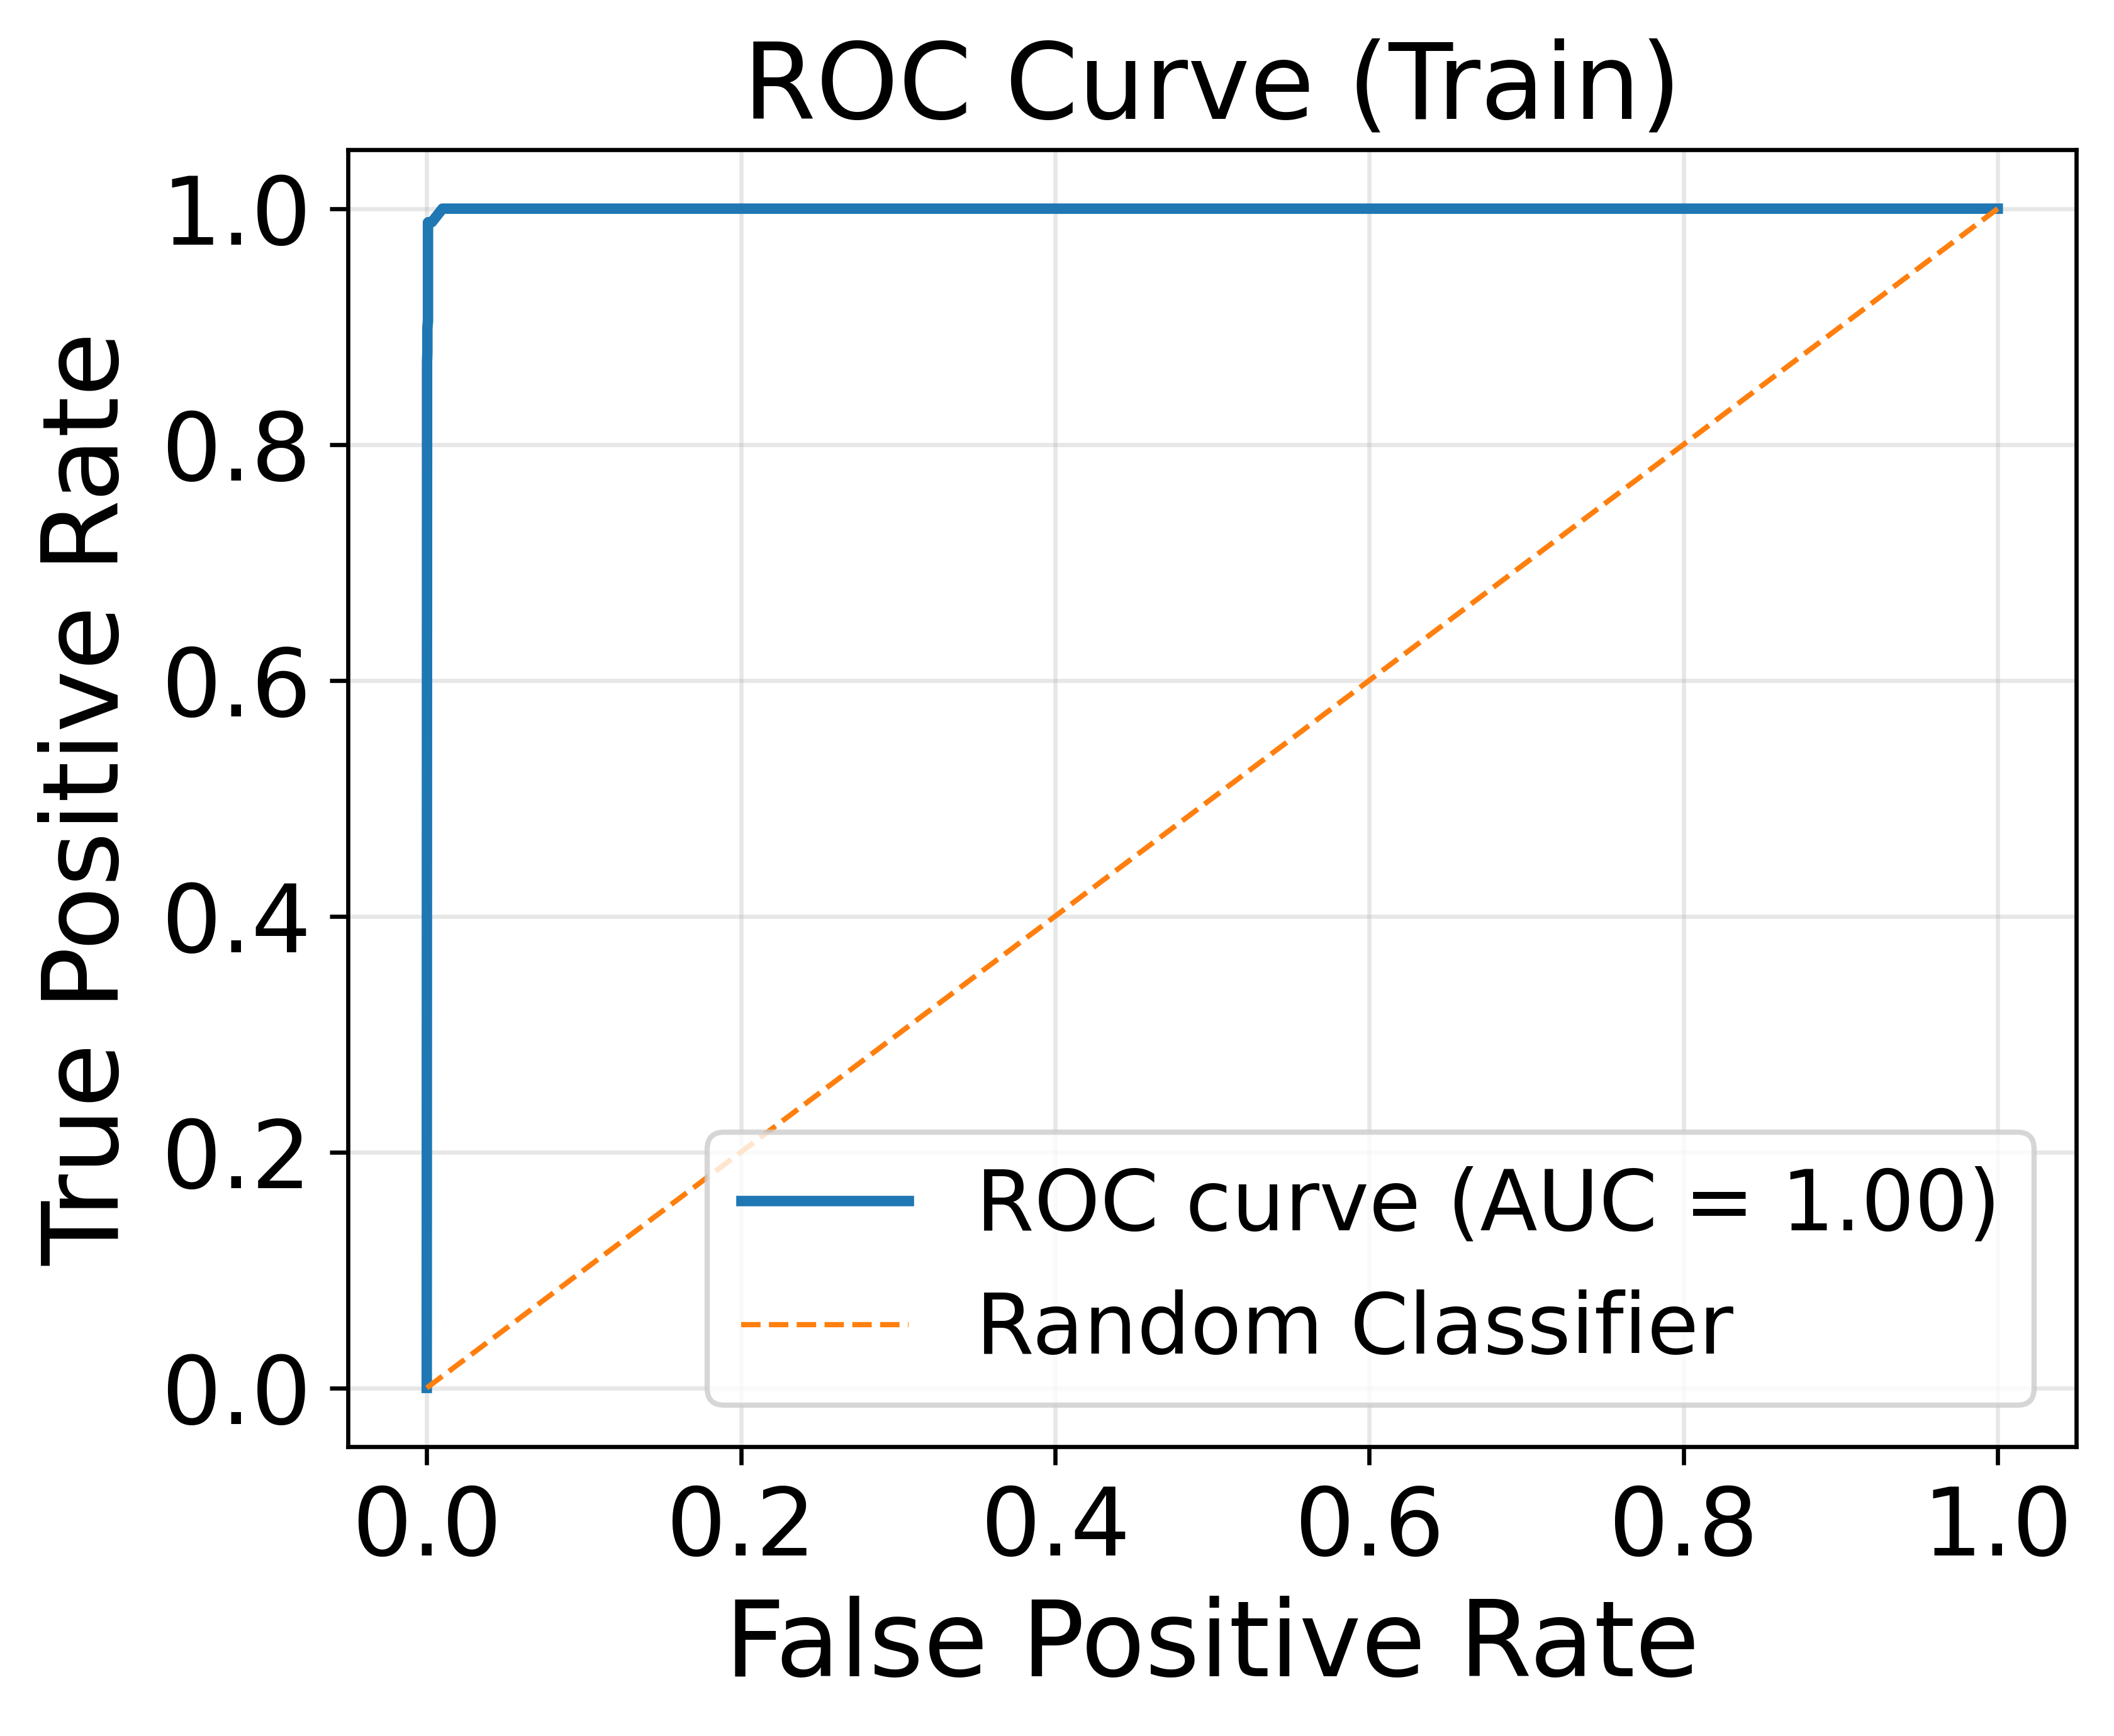


Evaluation Results: Validation
Accuracy  : 0.856609
Precision : 0.847628
Recall    : 0.869036
F1-score  : 0.858199
ROC AUC   : 0.924270
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.866029  0.844216  0.854983      1072
         1.0   0.847628  0.869036  0.858199      1069

    accuracy                       0.856609      2141
   macro avg   0.856828  0.856626  0.856591      2141
weighted avg   0.856841  0.856609  0.856589      2141



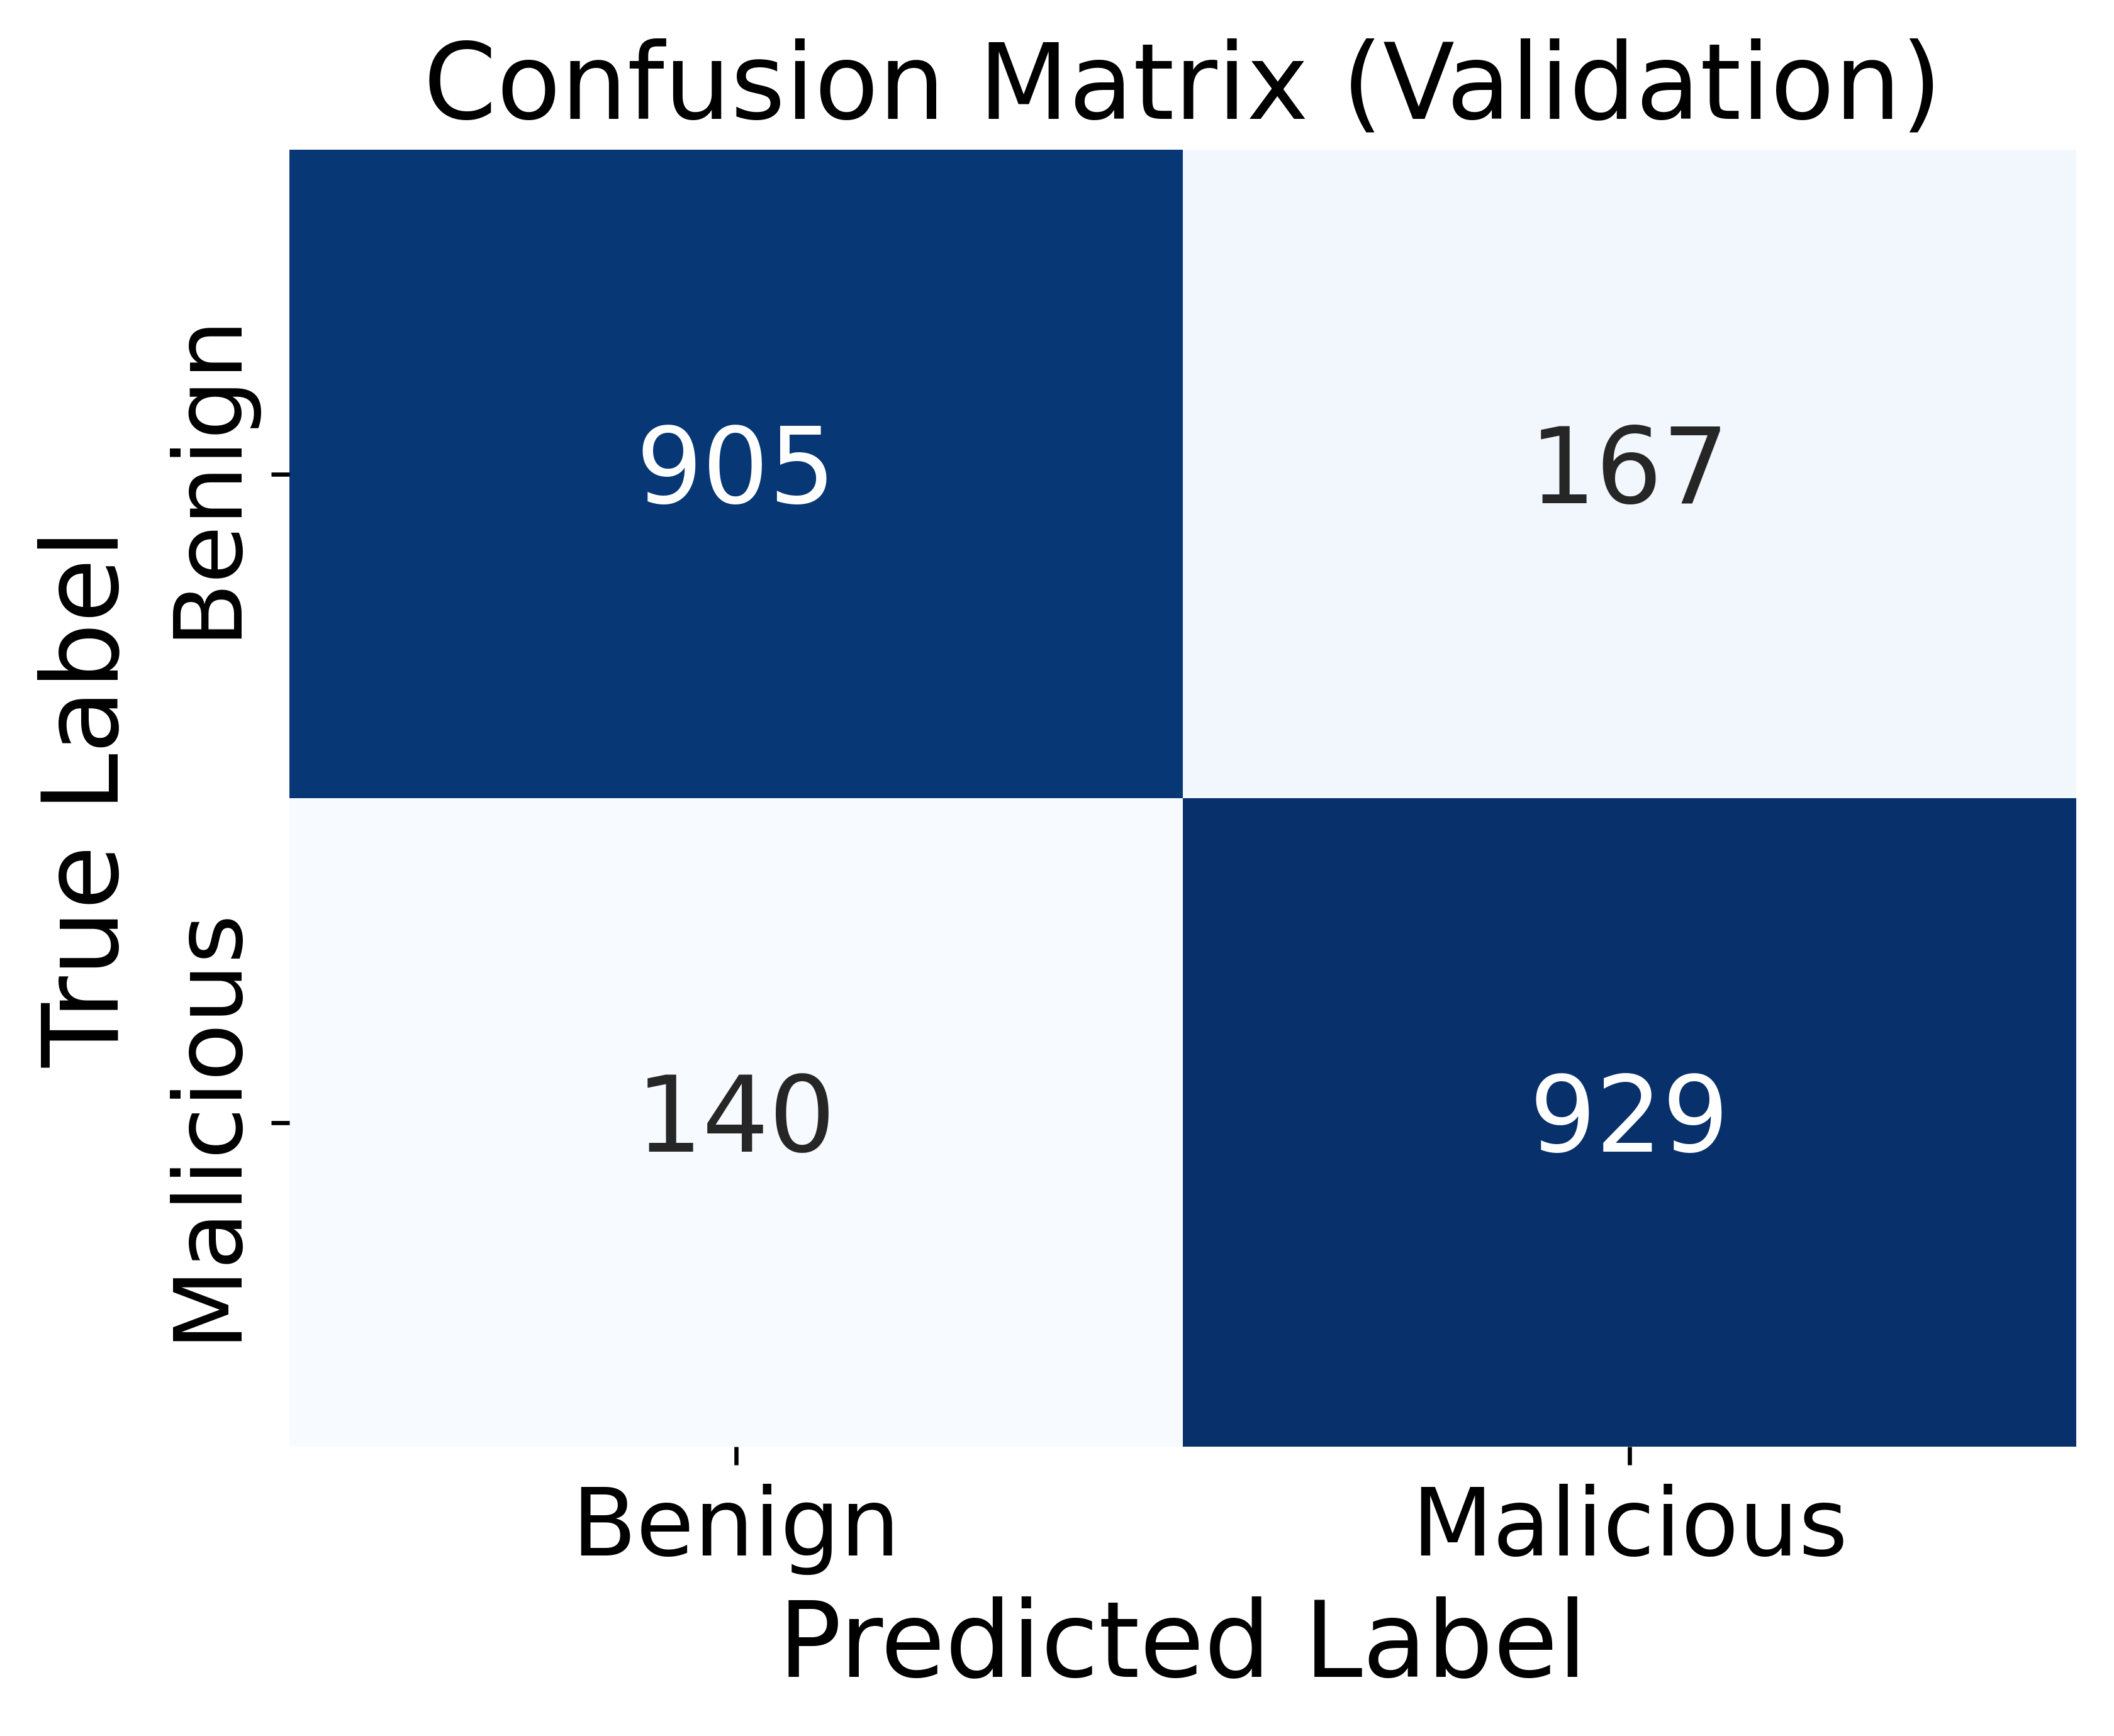

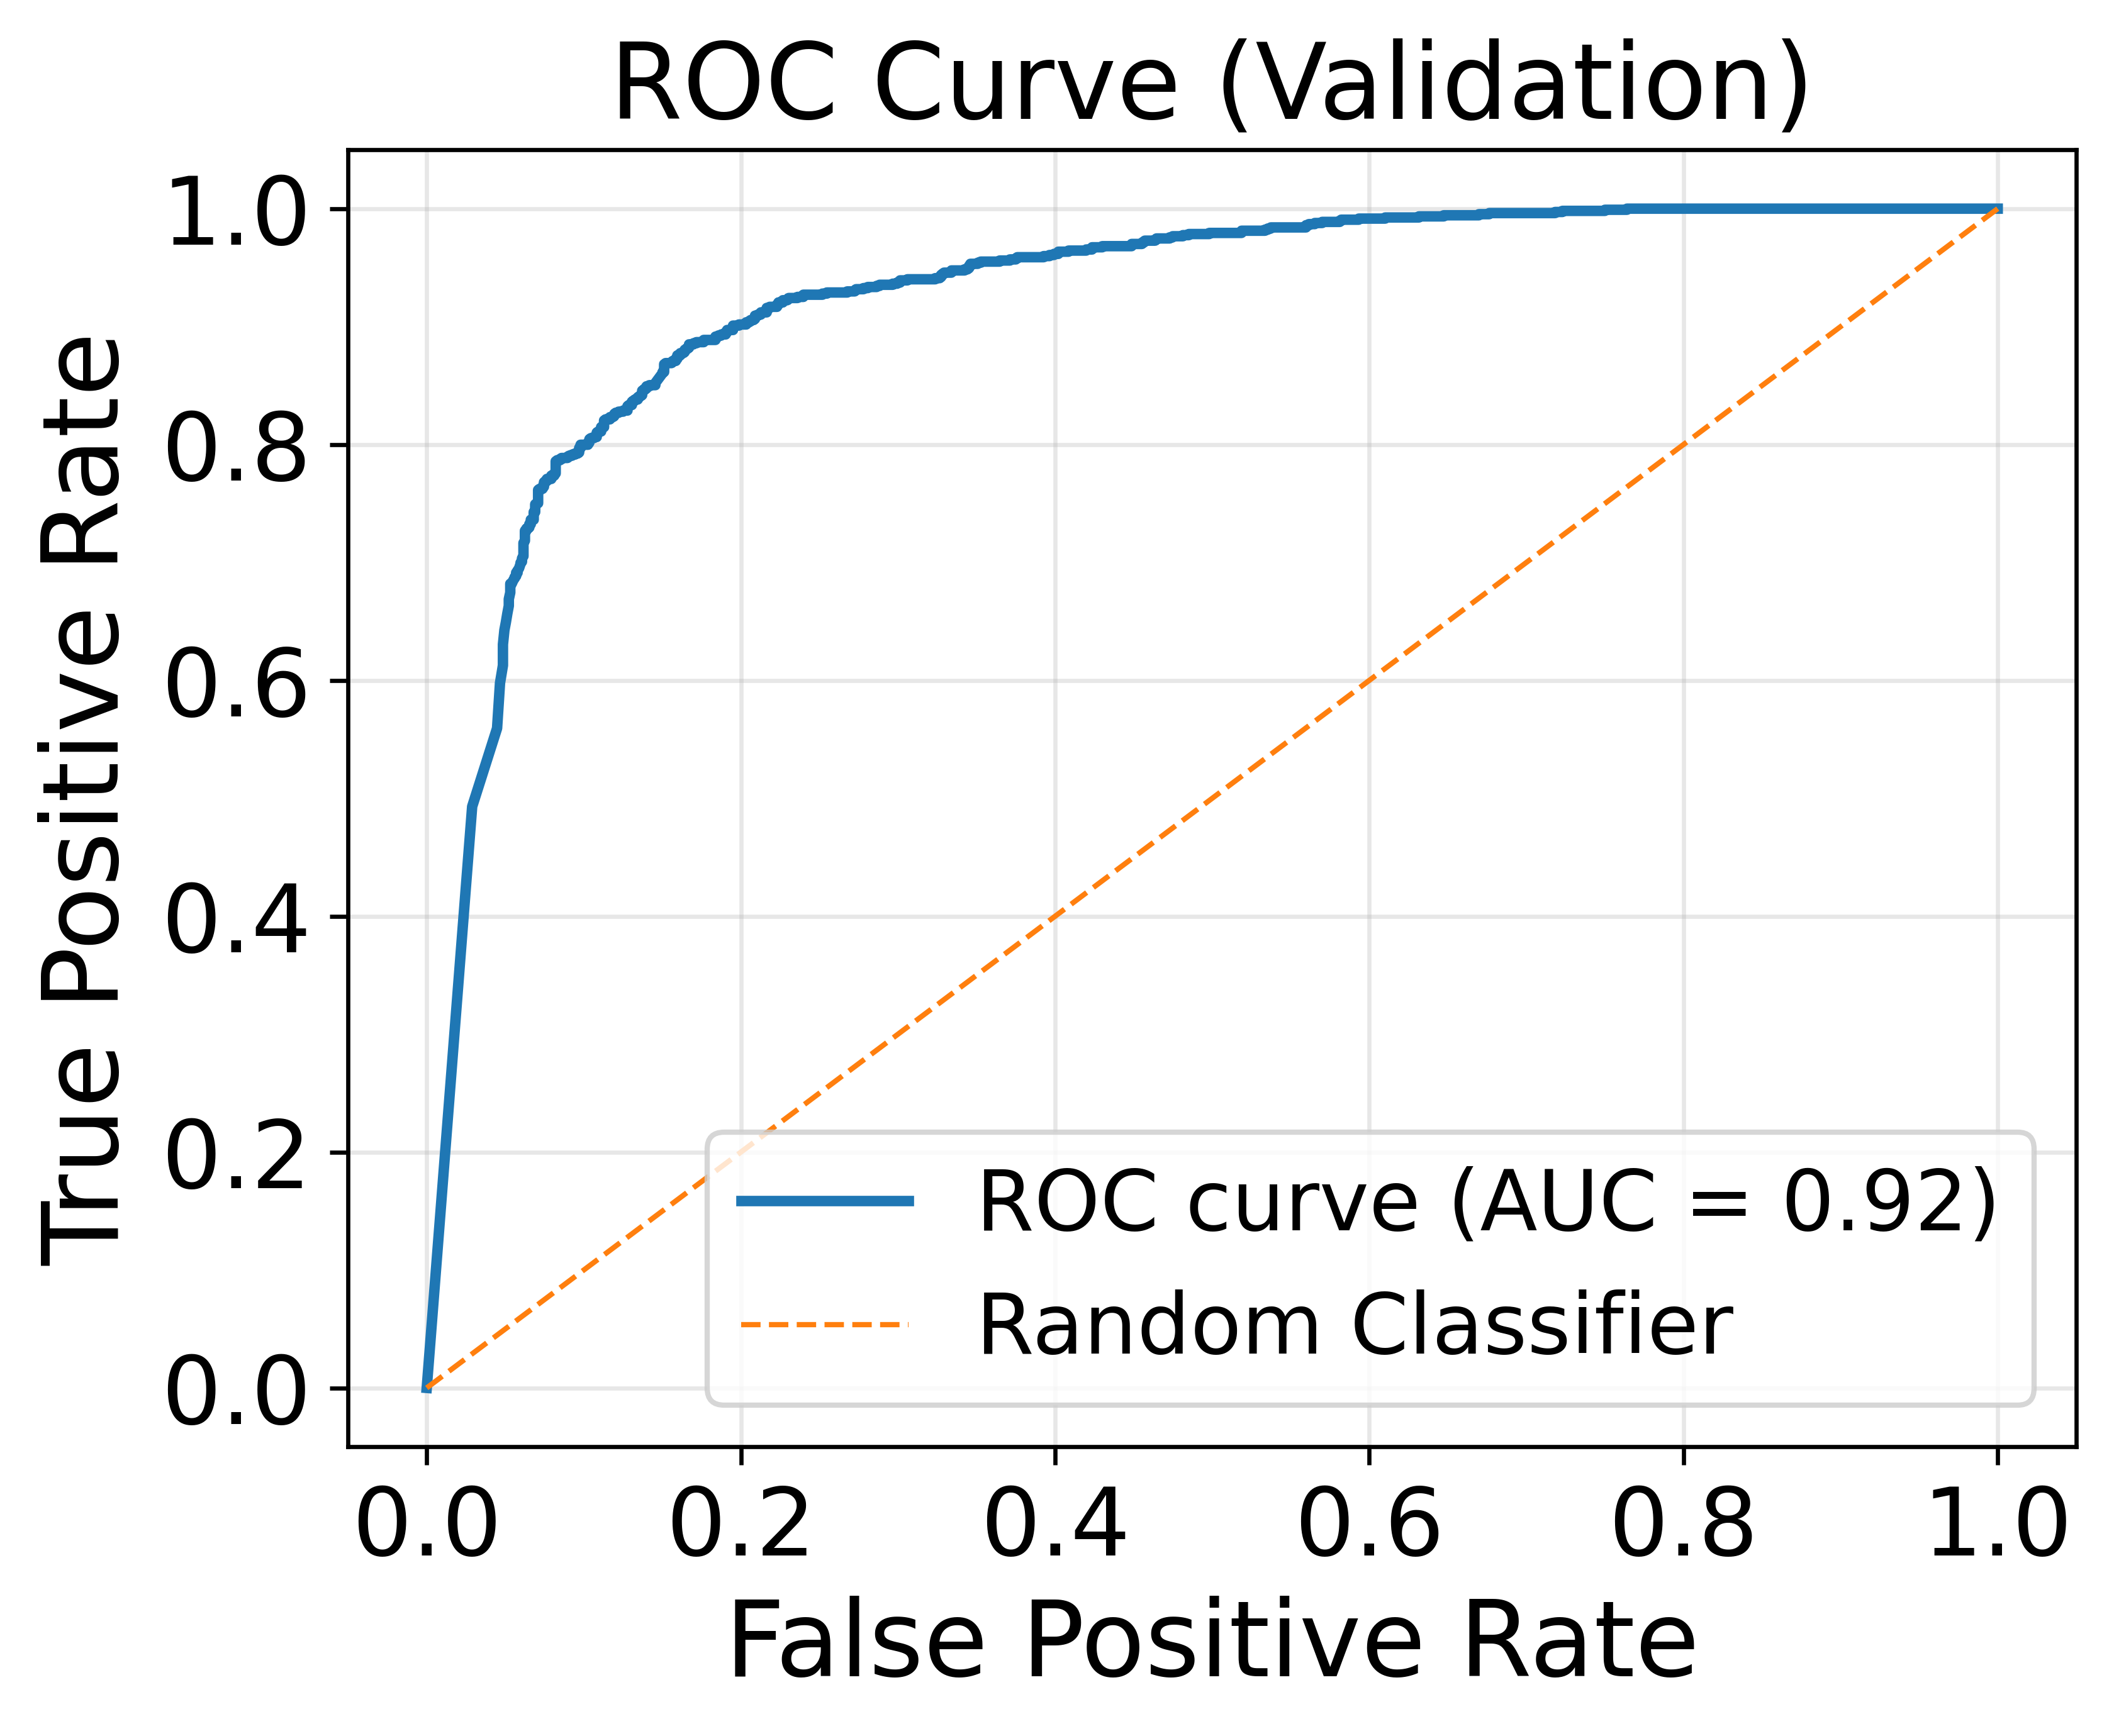


Evaluation Results: Test
Accuracy  : 0.852872
Precision : 0.842727
Recall    : 0.867166
F1-score  : 0.854772
ROC AUC   : 0.929037
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.863593  0.838619  0.850923      1072
         1.0   0.842727  0.867166  0.854772      1069

    accuracy                       0.852872      2141
   macro avg   0.853160  0.852892  0.852847      2141
weighted avg   0.853175  0.852872  0.852845      2141



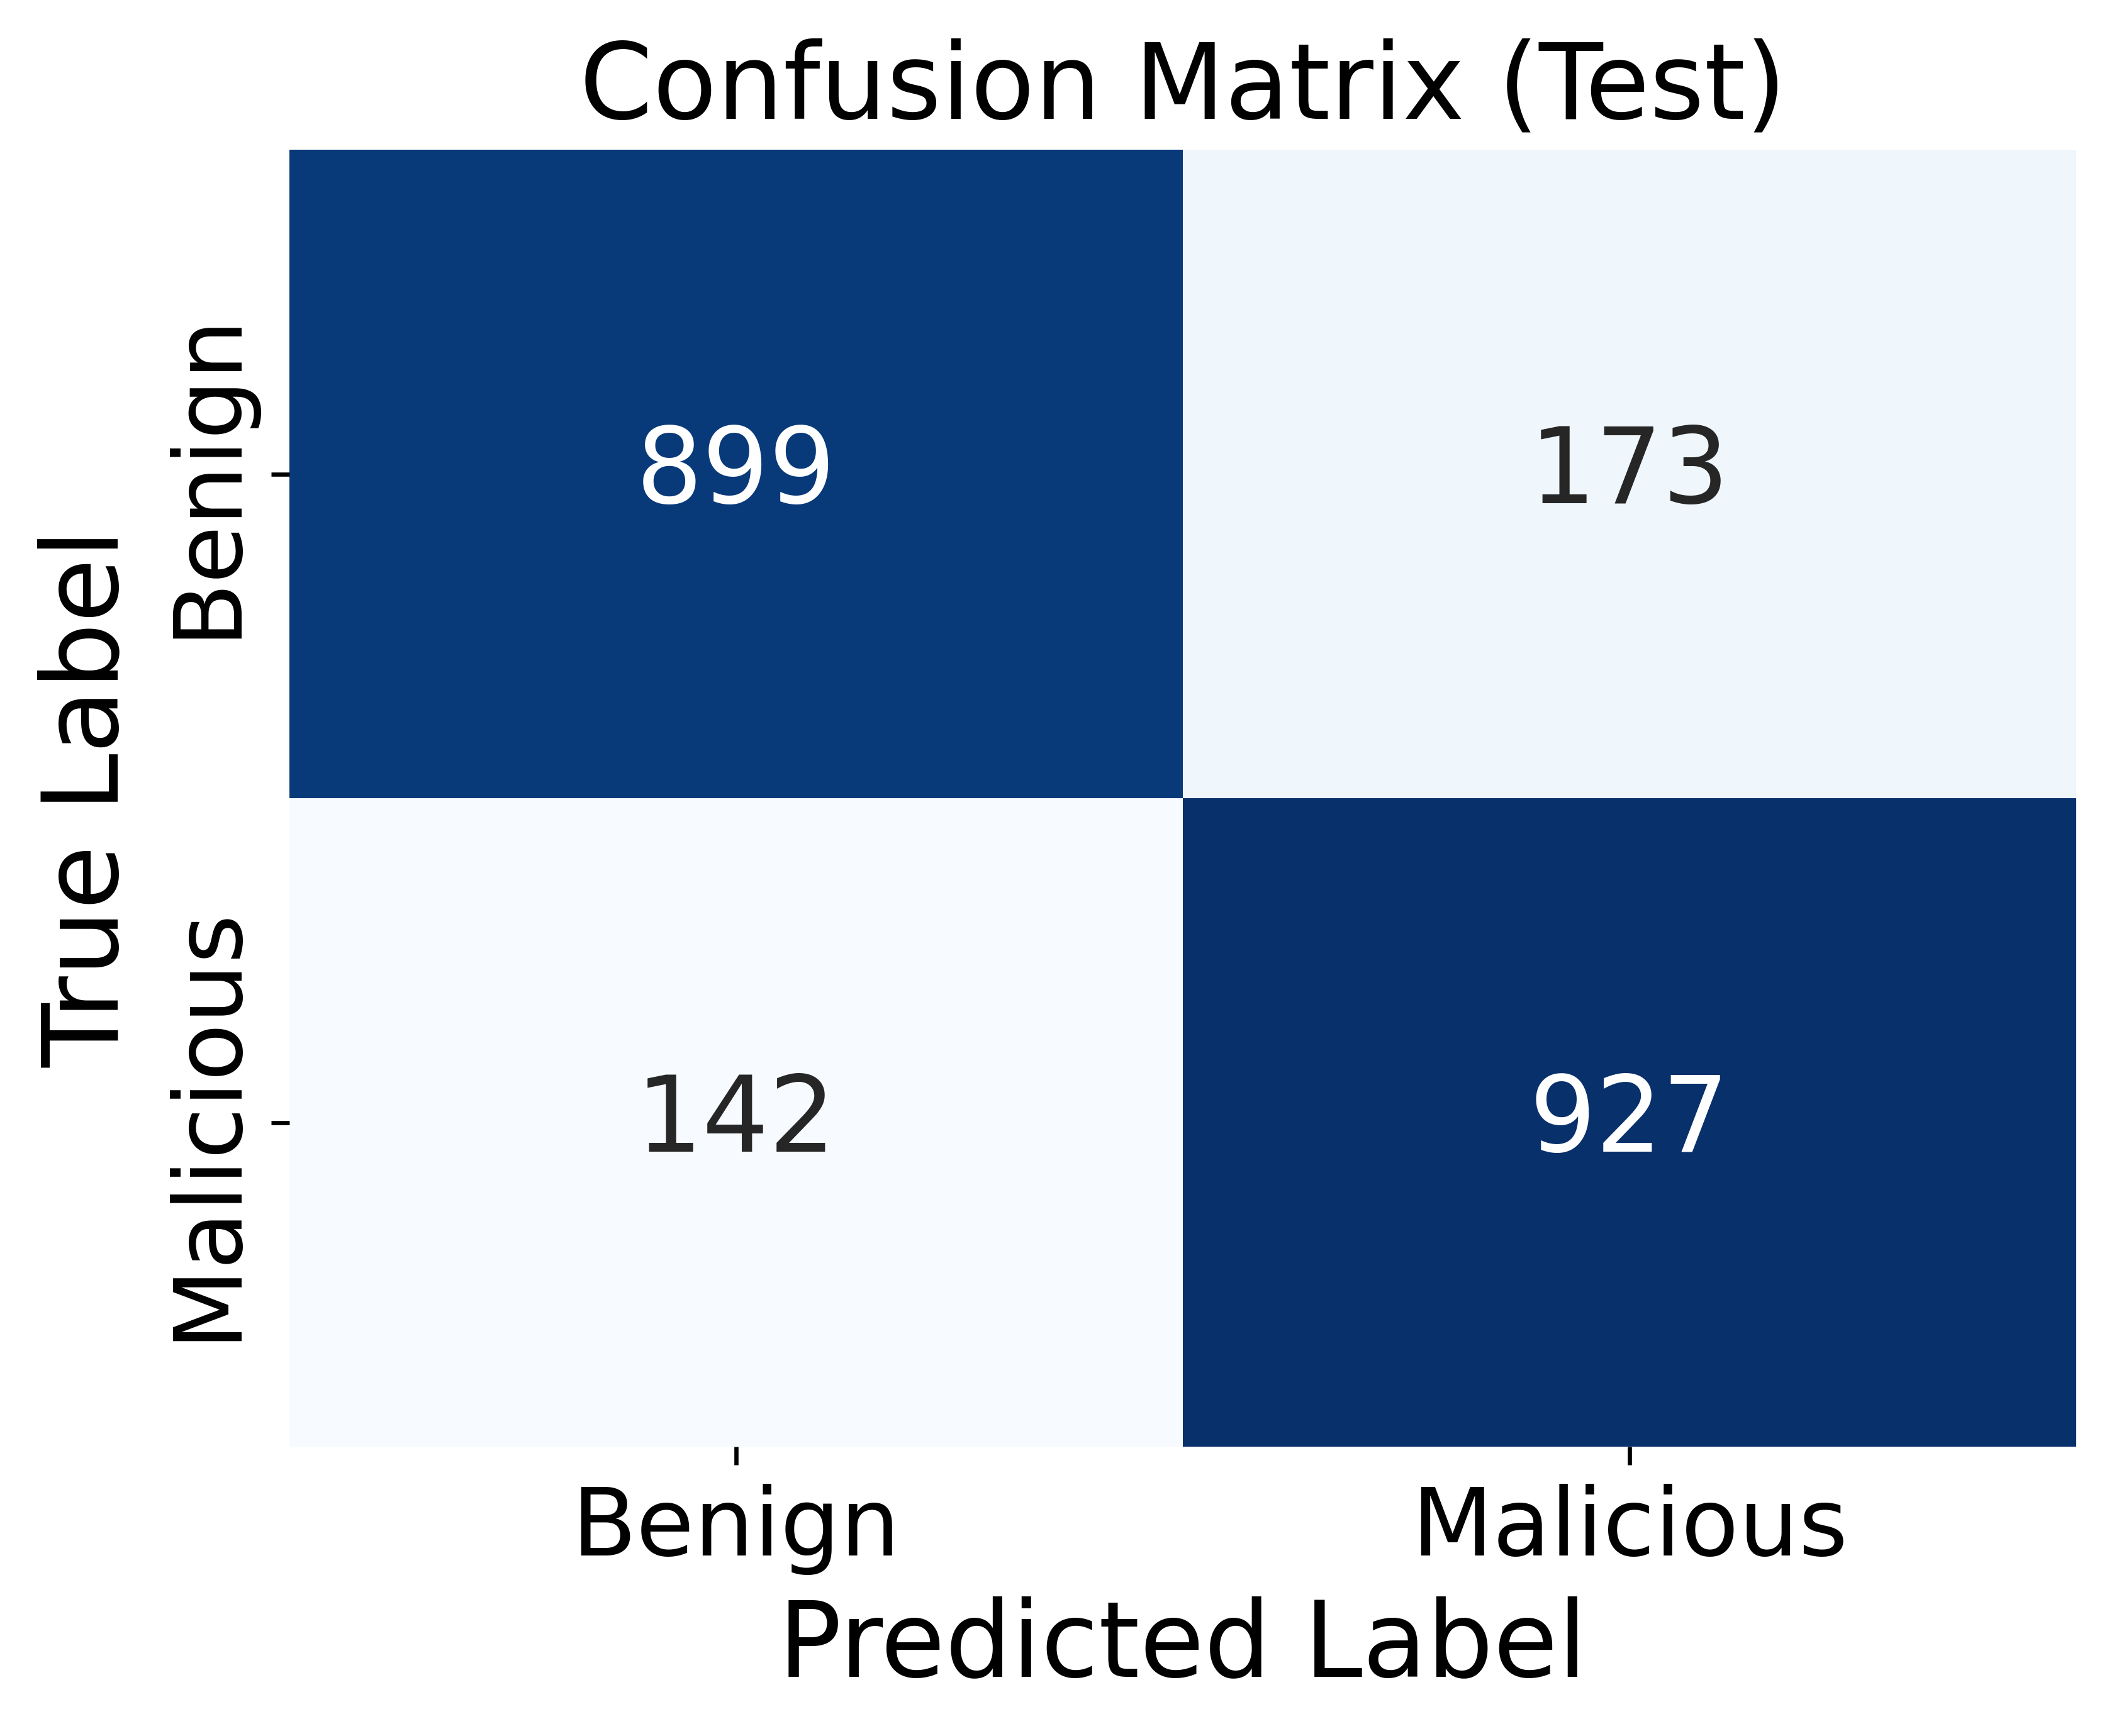

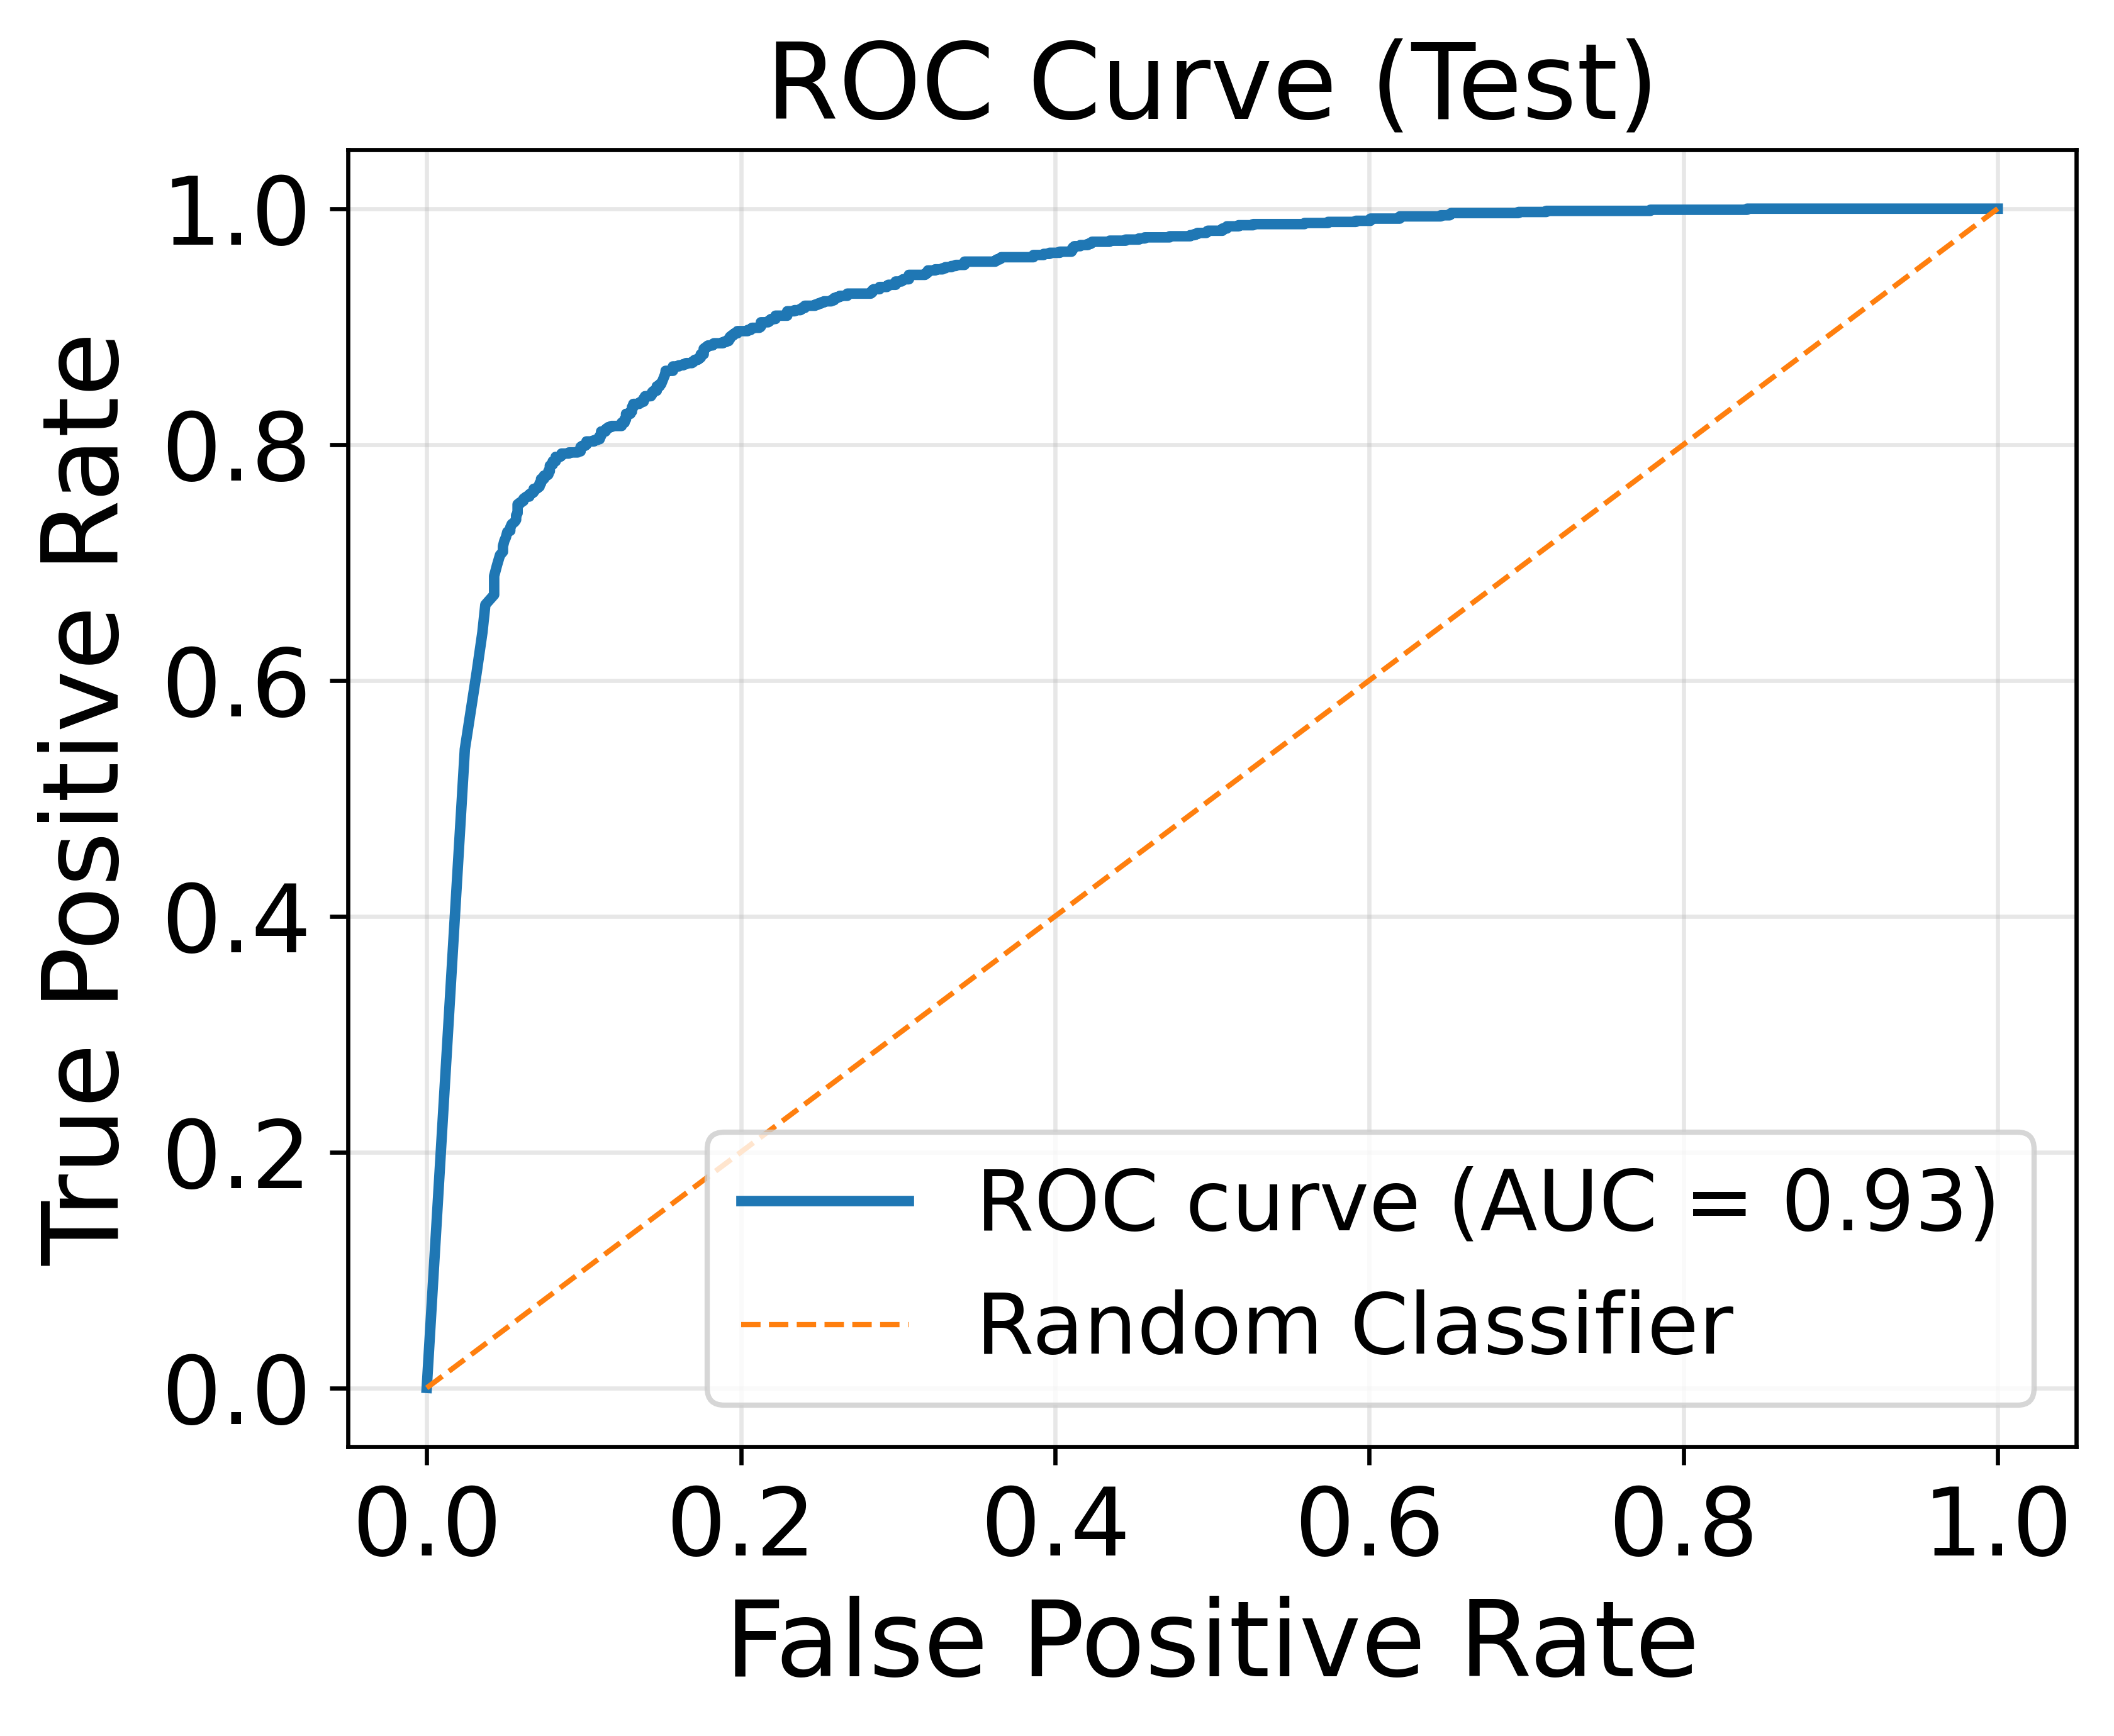

In [ ]:
def evaluate_and_plot(model, encodings, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Prepare model inputs
    # --------------------------------------------------------
    inputs = [
        np.array(encodings["input_ids"]),
        np.array(encodings["attention_mask"])
    ]

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(inputs, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, train_enc, y_train, "Train")
val_results   = evaluate_and_plot(model, val_enc, y_val, "Validation")
test_results  = evaluate_and_plot(model, test_enc, y_test, "Test")

### Save All Results

In [ ]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Filetop_WOA_Attention_BERT\evaluation_summary.csv
Excel: Evaluation_Outputs_Filetop_WOA_Attention_BERT\evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.994794,0.989685,1.000000,0.994816,0.999736
1,Validation,0.856609,0.847628,0.869036,0.858199,0.924270
2,Test,0.852872,0.842727,0.867166,0.854772,0.929037


### Clear Final Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()